In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI as genai
from langchain_community.document_loaders import PyMuPDFLoader, CSVLoader, DirectoryLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.tools import tool


d:\langgraph\langrph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HP\AppData\Local\Temp\ipykernel_1292\68061742.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader, CSVLoader, DirectoryLoader


In [2]:
load_dotenv()

False

In [10]:
llm=genai(
    model="gemini-2.5-flash"
)


In [11]:
class ultimate_state(TypedDict):
    patient_id: str
    patient_name: str
    patient_dept: str
    patient_doctor: str
    user_name: str
    user_query: str
    user_intent: str

    final_response: str
    medication_data: str
    recieved_documents: list
    retrieved_context: str
    analysis_result: str

    intent_agent: str
    reportanalyzer_agent: str

    # Required for LangGraph tool-calling flow
    messages: Annotated[list, add_messages]
    chat_history: list


In [12]:
def user_query(state: ultimate_state) -> ultimate_state:
    # The chatbot UI supplies the query. This graph node must never call input().
    query = (state.get("user_query") or "").strip()
    if not query:
        raise ValueError("No user query was supplied to the chatbot.")

    return {
        "user_query": query,
        "messages": [HumanMessage(content=query)]
    }


In [13]:
class user_intent(BaseModel):
    intent: Literal[
        "seeking factual data",
        "seeking reports analyzation",
        "seeking medication analysis",
        "general medical context",
        "doctoral prescription and medical records"
    ]


def intent_agent(state: ultimate_state) -> ultimate_state:
    prompt = PromptTemplate(
        template="""
You are a router agent. Your only job is to identify the intent of the
user query and return exactly ONE of the allowed categories.

Allowed categories:
- seeking factual data
- seeking reports analyzation
- seeking medication analysis
- general medical context
- doctoral prescription and medical records

User query:
{user_query}
""",
        input_variables=["user_query"]
    )

    formatted_prompt = prompt.format(
        user_query=state["user_query"]
    )

    structured_llm = llm.with_structured_output(user_intent)
    result = structured_llm.invoke(formatted_prompt)

    return {
        "user_intent": result.intent,
        "intent_agent": result.intent
    }


factual data

In [14]:
'''  
comng soon 

'''
pass

rag tool for multiagent framework

In [15]:
from pathlib import Path

DOCS_DIR = Path(r"D:\langgraph\kutaksha rag\docs")

if not DOCS_DIR.exists():
    raise FileNotFoundError(f"RAG docs folder not found: {DOCS_DIR}")

pdfloader = DirectoryLoader(
    str(DOCS_DIR),
    glob="*.pdf",
    loader_cls=PyMuPDFLoader
)

pdf_docs = pdfloader.load()
print("PDF documents loaded:", len(pdf_docs))
if pdf_docs:
    print("PDF sources:")
    for d in sorted({d.metadata.get("source", "unknown") for d in pdf_docs}):
        print(" -", d)


In [16]:
csvloader = DirectoryLoader(
    str(DOCS_DIR),
    glob="*.csv",
    loader_cls=CSVLoader
)

csv_docs = csvloader.load()
print("CSV documents loaded:", len(csv_docs))

# Keep PDF and CSV corpora separate.
# Medical report questions should NOT compete with large sensor CSVs.
docs = pdf_docs + csv_docs
print("Total documents loaded into RAG:", len(docs))


In [17]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

pdf_chunks = splitter.split_documents(pdf_docs)
csv_chunks = splitter.split_documents(csv_docs)
chunks = pdf_chunks + csv_chunks

print("PDF chunks:", len(pdf_chunks))
print("CSV chunks:", len(csv_chunks))
print("Total chunks:", len(chunks))


5448


In [18]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Main corpus for general/factual retrieval.
vector_Store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)
retriever = vector_Store.as_retriever(search_kwargs={"k": 5})

# IMPORTANT: dedicated medical-report index.
# This prevents sensor CSV chunks from drowning out the actual PDF report.
if not pdf_chunks:
    raise ValueError("No PDF chunks were created. Put the Case 102 medical PDF inside the docs folder.")

medical_vector_store = FAISS.from_documents(
    documents=pdf_chunks,
    embedding=embeddings
)
medical_retriever = medical_vector_store.as_retriever(search_kwargs={"k": 5})

print("RAG indexes ready: general + medical_reports")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2877.25it/s]


In [19]:
from typing import List,Optional
from pydantic import Field

In [20]:
class report_agent_schema(BaseModel):
     patient_id: str = Field(
        description="The patient whose medical information is required."
    )
     patient_name:str=Field(
          description="the patient name whose medical information is required"
     )

     information_required: str = Field(
        description="Exactly what medical information is needed to answer the user's query."
    )

     search_query: str = Field(
        description="A focused semantic search query to retrieve the relevant medical reports."
    )

     document_types: List[str] = Field(
        description="Types of documents that should be retrieved, such as medical_report, doctor_note, prescription, diagnosis."
    )

     date_from: Optional[str] = Field(
        default=None,
        description="Start date of the relevant period, if specified or required."
    )

     date_to: Optional[str] = Field(
        default=None,
        description="End date of the relevant period, if specified or required."
    )

     retrieval_reason: str = Field(
        description="Why these specific documents/information are necessary for the user's query."
    )

In [21]:
class reportanalyzer_output(BaseModel):
    report: str = Field(
        description="The report generated from the retrieved medical documents according to the user's query."
    )
    keyfindings: list[str] = Field(
        description="Important findings identified from the retrieved medical documents."
    )
    resources: list[str] = Field(
        description="Sources or documents used to generate the report."
    )


# Structured-output LLMs are created after their schemas are defined.
report_output_llm = llm.with_structured_output(reportanalyzer_output)


In [22]:
@tool
def rag_search(user_query: str, search_type: str = "general") -> str:
    """Retrieve relevant information from the patient knowledge base.

    search_type='medical_report' searches only medical-report PDFs.
    search_type='general' searches the complete corpus.
    """
    query = (user_query or "").strip()
    if not query:
        return "No query was supplied to RAG."

    active_retriever = medical_retriever if search_type == "medical_report" else retriever
    retrieved_docs = active_retriever.invoke(query)

    if not retrieved_docs:
        return "No relevant information found in the RAG knowledge base."

    results = []
    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get("source", "unknown source")
        page = doc.metadata.get("page")
        location = f"{source}" + (f" | page {page + 1}" if isinstance(page, int) else "")
        results.append(f"RESULT {i}\nSOURCE: {location}\n{doc.page_content}")

    return "\n\n---\n\n".join(results)

# Tool binding is kept for the LangGraph agentic path.
llm_with_rag = llm.bind_tools([rag_search])


In [23]:
def reportanalyzer_agent(state: ultimate_state) -> ultimate_state:
    """Retrieve evidence from the dedicated medical-report RAG index."""
    query = state["user_query"]

    retrieved = rag_search.invoke({
        "user_query": query,
        "search_type": "medical_report"
    })

    return {
        "retrieved_context": retrieved,
        "recieved_documents": [retrieved],
        "reportanalyzer_agent": "medical report retrieval completed"
    }


def report_analysis(state: ultimate_state) -> ultimate_state:
    # Read the RAG result directly from state. Do not depend on message ordering.
    retrieved_information = state.get("retrieved_context", "")

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are a medical-report analysis assistant.
Answer the user's query using ONLY the retrieved medical report below.
Give a clear, useful answer with:
1. Key findings
2. Relevant clinical details
3. Source used
Do not invent missing facts, diagnose, or prescribe.
If the retrieved text says no relevant information was found, say so."""
        ),
        (
            "human",
            "User Query:\n{user_query}\n\nRetrieved Medical Report:\n{retrieved_information}"
        )
    ])

    formatted = prompt.format_messages(
        user_query=state["user_query"],
        retrieved_information=retrieved_information
    )

    # Keep Pydantic structured output for predictable fields.
    result = report_output_llm.invoke(formatted)

    answer = result.report.strip() if result.report else "No report analysis was generated."
    findings = "\n".join(f"- {x}" for x in result.keyfindings) if result.keyfindings else "- No key findings extracted."
    sources = "\n".join(f"- {x}" for x in result.resources) if result.resources else "- Retrieved medical report"

    final_answer = (
        f"{answer}\n\n"
        f"Key Findings:\n{findings}\n\n"
        f"Sources:\n{sources}"
    )

    return {
        "analysis_result": final_answer,
        "reportanalyzer_agent": final_answer,
        "recieved_documents": result.resources
    }


In [24]:
class medication_agent_schema(BaseModel):
    patient_id:str
    patient_name:str

    document_types: list[str] = Field(
        description="Relevant document types such as prescription, medication_record, doctor_note, or medical_report.")

In [25]:
class medication_agent_output(BaseModel):
    prescribed_medications: list[str] = Field(
        description="Medications prescribed to the patient based on the retrieved documents."
    )
    medication_changes: list[str] = Field(
        description="Relevant changes in medication, dosage, or prescription found in the retrieved documents."
    )
    key_findings: list[str] = Field(
        description="Important medication-related findings from the retrieved information."
    )
    analysis: str = Field(
        description="Analysis of the patient's medication information based only on the retrieved documents."
    )
    sources: list[str] = Field(
        description="Sources or documents used for the medication analysis."
    )


medication_output_llm = llm.with_structured_output(medication_agent_output)


In [26]:
def medication_agent(state: ultimate_state) -> ultimate_state:
    query = state["user_query"]
    retrieved = rag_search.invoke({
        "user_query": query,
        "search_type": "medical_report"
    })

    return {
        "retrieved_context": retrieved,
        "recieved_documents": [retrieved],
        "medication_data": "retrieval completed"
    }


def medication_analysis(state: ultimate_state) -> ultimate_state:
    retrieved_information = state.get("retrieved_context", "")

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """Analyze the retrieved medication information and generate the answer
using ONLY the retrieved documents. Do not invent or assume medication information.
Do not prescribe new medication."""
        ),
        (
            "human",
            "User Query:\n{user_query}\n\nRetrieved Information:\n{retrieved_information}"
        )
    ])

    formatted = prompt.format_messages(
        user_query=state["user_query"],
        retrieved_information=retrieved_information
    )

    result = medication_output_llm.invoke(formatted)

    return {
        "analysis_result": result.analysis,
        "medication_data": result.model_dump_json()
    }


## LangGraph orchestration

In [27]:
from langgraph.prebuilt import ToolNode

rag_tool_node = ToolNode([rag_search])


def intent_router(state: ultimate_state):
    intent = state["user_intent"]

    if intent == "seeking reports analyzation":
        return "report_agent"
    if intent == "seeking medication analysis":
        return "medication_agent"

    # Factual, general medical context, and medical-record questions
    # all need evidence from the medical-report corpus in this prototype.
    return "general_answer"


def agent_tool_router(state: ultimate_state):
    if state["user_intent"] == "seeking reports analyzation":
        return "report_analysis"
    if state["user_intent"] == "seeking medication analysis":
        return "medication_analysis"
    return "end"


def rag_result_router(state: ultimate_state):
    if state["user_intent"] == "seeking reports analyzation":
        return "report_analysis"
    if state["user_intent"] == "seeking medication analysis":
        return "medication_analysis"
    return "general_analysis"


def general_answer(state: ultimate_state) -> ultimate_state:
    # IMPORTANT: records/factual/general medical questions must search the
    # medical PDF index, not the large sensor-data index.
    query = state["user_query"]
    retrieved = rag_search.invoke({
        "user_query": query,
        "search_type": "medical_report"
    })

    return {
        "retrieved_context": retrieved,
        "recieved_documents": [retrieved]
    }


def general_analysis(state: ultimate_state) -> ultimate_state:
    retrieved_information = state.get("retrieved_context", "")

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are a patient medical-record assistant.
Answer the user's question using the retrieved medical records below.

Rules:
- Use the retrieved records as the evidence.
- If the requested case/patient is present in the retrieved records, answer from it clearly.
- Do not claim that information is unavailable merely because the intent is 'medical records'.
- Only say information is unavailable when the retrieved context genuinely does not contain it.
- Do not invent patient facts.
- Do not diagnose or prescribe new treatment.
- Keep the answer concise but include the important clinical details and source when available."""
        ),
        (
            "human",
            "User Query:\n{user_query}\n\nRetrieved Medical Records:\n{retrieved_information}"
        )
    ])

    result = llm.invoke(
        prompt.format_messages(
            user_query=state["user_query"],
            retrieved_information=retrieved_information
        )
    )

    return {"analysis_result": result.content}


In [28]:
workflow = StateGraph(ultimate_state)

workflow.add_node("user_query", user_query)
workflow.add_node("intent_agent", intent_agent)
workflow.add_node("report_agent", reportanalyzer_agent)
workflow.add_node("medication_agent", medication_agent)
workflow.add_node("general_answer", general_answer)
workflow.add_node("rag_tool", rag_tool_node)
workflow.add_node("report_analysis", report_analysis)
workflow.add_node("medication_analysis", medication_analysis)
workflow.add_node("general_analysis", general_analysis)

workflow.add_edge(START, "user_query")
workflow.add_edge("user_query", "intent_agent")

workflow.add_conditional_edges(
    "intent_agent",
    intent_router,
    {
        "report_agent": "report_agent",
        "medication_agent": "medication_agent",
        "general_answer": "general_answer"
    }
)

workflow.add_conditional_edges(
    "report_agent",
    agent_tool_router,
    {
        "rag_tool": "rag_tool",
        "report_analysis": "report_analysis",
        "end": END
    }
)

workflow.add_conditional_edges(
    "medication_agent",
    agent_tool_router,
    {
        "rag_tool": "rag_tool",
        "medication_analysis": "medication_analysis",
        "end": END
    }
)

workflow.add_conditional_edges(
    "rag_tool",
    rag_result_router,
    {
        "report_analysis": "report_analysis",
        "medication_analysis": "medication_analysis",
        "general_analysis": "general_analysis"
    }
)

workflow.add_edge("general_answer", "general_analysis")
workflow.add_edge("report_analysis", END)
workflow.add_edge("medication_analysis", END)
workflow.add_edge("general_analysis", END)

app = workflow.compile()


In [ ]:
# RAG sanity check -- run this once before using the chatbot.
print("\nRAG SANITY CHECK")
print("Medical PDF chunks:", len(pdf_chunks))

test_results = medical_retriever.invoke(
    "case 102 undetected subdural hematoma Warfarin ground-level fall"
)

for i, doc in enumerate(test_results, 1):
    print(f"\n--- Retrieved result {i} ---")
    print("SOURCE:", doc.metadata.get("source", "unknown"))
    print(doc.page_content[:1200])


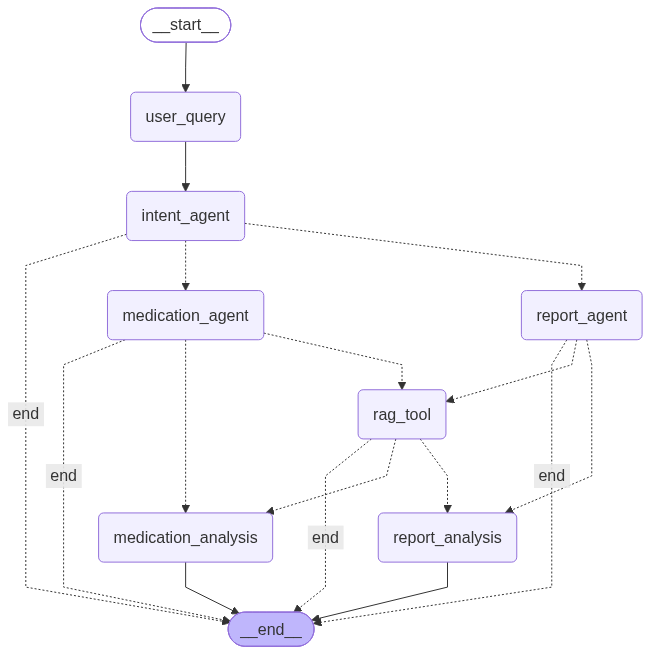

In [32]:
# Simple terminal-style chatbot -- no ipywidgets
chat_history = []

def chat_once():
    print("\n" + "=" * 70)
    print("PATIENT MONITORING AI CHATBOT")
    print("=" * 70)
    print("Type your question. Type 'exit' to stop.")

    query = input("\nYou: ").strip()

    if query.lower() in {"exit", "quit", "q"}:
        print("Chatbot: Goodbye!")
        return

    if not query:
        print("Chatbot: Please enter a question.")
        return

    try:
        final_state = app.invoke({
            "user_query": query,
            "chat_history": chat_history,
            "messages": []
        })

        intent = final_state.get("user_intent", "unknown")
        answer = final_state.get("analysis_result")

        print(f"\nIntent: {intent}")
        print("\nChatbot:")
        print(answer if answer else "No final answer was returned by the analysis node.")

        chat_history.append({"user": query, "assistant": str(answer)})

    except Exception as e:
        print(f"\nChatbot error: {type(e).__name__}: {e}")
        raise

chat_once()

from IPython.display import Image, display
print("\nLangGraph Architecture:")
display(Image(app.get_graph().draw_mermaid_png()))
